# Semantic Segmentation

Notebook for training semantic segmentation

In [ ]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [1]:
from fastai.vision.all import *
print(torch.cuda.get_device_name(0))
print(torch.__version__)

NVIDIA A100-SXM4-40GB
2.9.1+cu128


In [2]:
# fix Random seed 
import random
torch.manual_seed(0) # pyTorch
random.seed(0)       # python

#print(random.random())

In [3]:
import gc
torch.cuda.empty_cache()
gc.collect()

0

In [4]:
from pathlib import Path
path = Path('../data/training') 

path.ls() 


[Path('../data/training/images'), Path('../data/training/masks')]

Create two paths, one for images and one for labels.

In [5]:
path_images = path/'images'
path_labels = path/'masks'

## Check Data

In [6]:
file_names = get_image_files(path_images) 

file_names[:3]

[Path('../data/training/images/pcb_0002_jpg.rf.ab3ccd133e4d96957dec314e2a438c84.jpg'), Path('../data/training/images/pcb_0008_jpg.rf.8f989c9c758f85f34b1879a45640ab10.jpg'), Path('../data/training/images/pcb_0009_jpg.rf.e361c06113c5d106f957030235f55036.jpg')]

In [7]:
label_names = get_image_files(path_labels)

label_names[:3]

[Path('../data/training/masks/pcb_0002_jpg.rf.ab3ccd133e4d96957dec314e2a438c84.jpg'), Path('../data/training/masks/pcb_0008_jpg.rf.8f989c9c758f85f34b1879a45640ab10.jpg'), Path('../data/training/masks/pcb_0009_jpg.rf.e361c06113c5d106f957030235f55036.jpg')]

Mapping the folders, as the image name = label name

In [8]:
def label_function(filename):
    return path_labels / Path(filename.stem + filename.suffix )

In [9]:
print( file_names[0] )
print( label_function(file_names[0]) )

../data/training/images/pcb_0002_jpg.rf.ab3ccd133e4d96957dec314e2a438c84.jpg
../data/training/masks/pcb_0002_jpg.rf.ab3ccd133e4d96957dec314e2a438c84.jpg


Display the associated label image:

In [10]:
import matplotlib.pyplot as plt
import numpy

image = load_image(file_names[3])
mask = load_image(label_function(file_names[3]))
mask2 = load_image(label_function(file_names[5]))

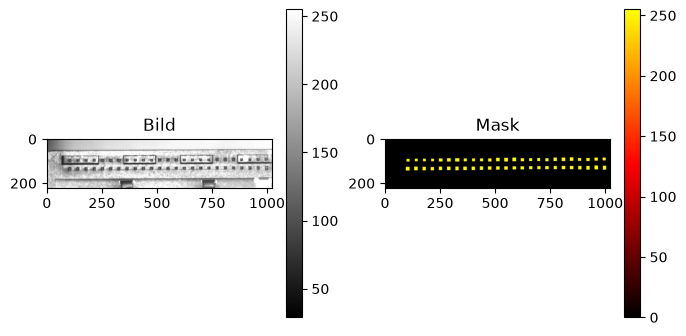

In [11]:
# custom ColorMap
import matplotlib as mp
cpts = [0.0, 0.5, 1.0]
colors = [(cpts[0], (0, 0, 0)), (cpts[1], (1.0, 0.0, 0.0)), (cpts[2], (1, 1, 0))]
cmap_name = 'my_list'
colormap = mp.colors.LinearSegmentedColormap.from_list(cmap_name, colors)


figure = plt.figure(figsize=(8,4))
axis = figure.add_subplot(1, 2, 1)
axis.set_title('Bild')
plt.imshow(image, cmap='gray')
plt.colorbar()
axis = figure.add_subplot(1, 2, 2)
axis.set_title('Mask')
display_mask = numpy.asarray(mask) 
plt.imshow(display_mask, cmap=colormap)
plt.colorbar()

Define Classes

In [12]:
print( mask.getextrema() )
codes = np.array(['background','pin']) #np.array(['background','pin', 'large'])
codes

(0, 255)


array(['background', 'pin'], dtype='<U10')

## Load Dataset

In [13]:
batch_transforms = [*aug_transforms(size=512), Normalize.from_stats(*imagenet_stats)]



def remap_mask(path):
    mask = PILMask.create(path)                 # load mask as PILMask
    mask_np = np.array(mask)                    # convert to NumPy array
    mask_np = (mask_np > 0).astype(np.uint8)    # everything >0 becomes 1
    return PILMask.create(mask_np)              # back as PILMask



datablocks = DataBlock(blocks=(ImageBlock, MaskBlock(codes=codes)),
                       get_items = get_image_files,
                       get_y=lambda o: remap_mask(label_function(o)),  
                       splitter=RandomSplitter(seed=42),
                       batch_tfms=batch_transforms)


#default: bs=8, num_workers=8
data_loader = datablocks.dataloaders(path_images, bs=8, num_workers=4 ) # recommended parameters: bs=4,8,12,16   num_workers=4,8,12,16

Check Masks if needed

In [14]:
# check:
print(type(data_loader))       # should be fastai.data.core.DataLoaders

xb, yb = data_loader.one_batch()
print(yb.unique())     # tensor([0, 1])
print("dtype Y:", yb.dtype)    

<class 'fastai.data.core.DataLoaders'>
TensorMask([0, 1], device='cuda:0')
dtype Y: torch.int64


Control: Minibatch 

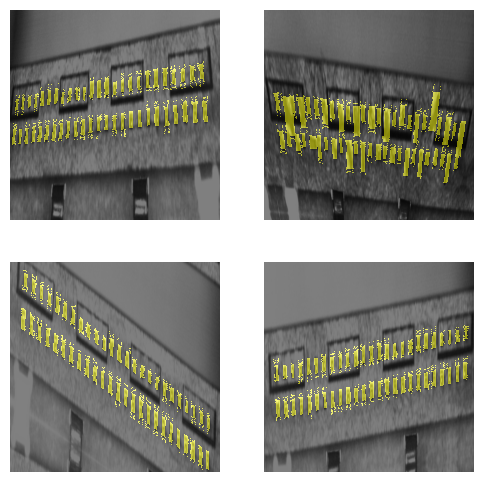

In [15]:
data_loader.show_batch( max_n=4, vmin=0, vmax=1, cmap=colormap )

## Metric

In [16]:
from fastai.torch_core import TensorBase

# Input is:
# Predictions in hot-1-encoding, format batchsize x n_classes x x_size x y_size, z.B. 4x2x128x128
# Target                         format batchsize x x_size x y_size,             z.B. 4x128x128
def original_accuracy(predictions, target):
    
    pred_hot1_decoded = predictions.argmax(dim=1)
 
    correct_predictions = ( TensorBase(pred_hot1_decoded) == TensorBase(target) )
    correct_predictions = correct_predictions.float()
    
    return correct_predictions.mean()

def accuracy_pin(predictions, target):   
    
    pred_hot1_decoded = predictions.argmax(dim=1)

    pin_in_target = target == 1   


    correct_pin = torch.logical_and( TensorBase(pin_in_target), TensorBase(pred_hot1_decoded) )
    correct_pin = correct_pin.float()       
    # recall metric
    return correct_pin.sum() / pin_in_target.float().sum()

In [17]:
metrics = [accuracy_pin, original_accuracy]

In [18]:

print(type(data_loader))
print(hasattr(data_loader, 'train'), hasattr(data_loader, 'valid'))
print(hasattr(data_loader, 'train_ds'), hasattr(data_loader, 'valid_ds'))


<class 'fastai.data.core.DataLoaders'>
True True
True True


## Model

In [19]:
from fastai.vision.all import *
import gc

# Clear GPU memory before creating model
torch.cuda.empty_cache()
gc.collect()

# default
learner = unet_learner(data_loader, resnet34, n_out=2, metrics=metrics, pretrained=True) # n_out=2 for background + one class


learner.loss_func

FlattenedLoss of CrossEntropyLoss()

Model Alternatives

In [ ]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from fastai.vision.all import *

model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)

# Adapt classifier for 2 classes (background + pin)
model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))  

# Wrap model to extract output from dict (DeepLabV3 returns a dict, not a tensor)
class DeepLabV3Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        return out['out']  # Extract tensor from dict

wrapped_model = DeepLabV3Wrapper(model)

# Create FastAI learner
learner = Learner(data_loader, wrapped_model, loss_func=DiceLoss(), metrics=metrics)

In [ ]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
from fastai.vision.all import *


model = fcn_resnet50(weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)

# Adapt classifier for 2 classes
model.classifier[4] = torch.nn.Conv2d(512, 2, kernel_size=(1, 1), stride=(1, 1))  

# Wrap model to extract output from dict (FCN returns a dict, not a tensor)
class FCNWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        return out['out']  # Extract tensor from dict

wrapped_model = FCNWrapper(model)

# Create FastAI learner
learner = Learner(data_loader, wrapped_model, loss_func=DiceLoss(), metrics=metrics)

In [ ]:
from torchvision.models.segmentation import lraspp_mobilenet_v3_large, LRASPP_MobileNet_V3_Large_Weights
from fastai.vision.all import *

# Load pre-trained LRASPP (weights from COCO)
model = lraspp_mobilenet_v3_large(weights=LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1)

# Adapt classifier for 2 classes
model.classifier.low_classifier = torch.nn.Conv2d(40, 2, kernel_size=(1, 1), stride=(1, 1))
model.classifier.high_classifier = torch.nn.Conv2d(128, 2, kernel_size=(1, 1), stride=(1, 1))

# Wrap model to extract output from dict (LRASPP returns a dict, not a tensor)
class LRASPPWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        return out['out']  # Extract tensor from dict

wrapped_model = LRASPPWrapper(model)

# Create FastAI learner
learner = Learner(data_loader, wrapped_model, loss_func=DiceLoss(), metrics=metrics)

In [20]:
# Garbage Collection
gc.collect()

9

In [21]:
learner.save("unet_roboflow")

Path('models/unet_roboflow.pth')

Check Device and Model to GPU

In [22]:
# 1) Modell-Device
try:
    print("Model device:", next(learner.model.parameters()).device)
except Exception as e:
    print("No Learn/Model found?", e)

# 2) DataLoader Batch-Devices
xb, yb = learner.dls.one_batch()
print("Batch devices:", getattr(xb, 'device', 'n/a'), getattr(yb, 'device', 'n/a'))

# 3) Fastai: to GPU (Mixed Precision for resnet50)
learner.to('cuda')

# Enable FP16 for resnet50 (reduces memory by ~50%)
try:
    learner.to_fp16()
    print("AMP active (fp16).")
except Exception as e:
    print("AMP not set:", e)

Model device: cpu


Batch devices: cuda:0 cuda:0
AMP active (fp16).


In [ ]:
# can lead to OOM error
#learner.lr_find()

In [23]:
learnrate = 0.001

In [24]:
learner.load("unet_roboflow")

with learner.no_bar(), learner.no_logging():
    learner.fit_one_cycle(25, learnrate) #default: 25 cycles

In [25]:
learner.save("unet_trained")

Path('models/unet_trained.pth')

In [ ]:
# preds = learner.get_preds() 

In [26]:

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current Device:", torch.cuda.current_device())
    print("GPU-Name:", torch.cuda.get_device_name(0))

CUDA available: True
Current Device: 0
GPU-Name: NVIDIA A100-SXM4-40GB


In [27]:

print("Learner Model Device:", next(learner.model.parameters()).device)
print("DataLoader Device:", learner.dls.device)

Learner Model Device: cuda:0
DataLoader Device: cuda:0


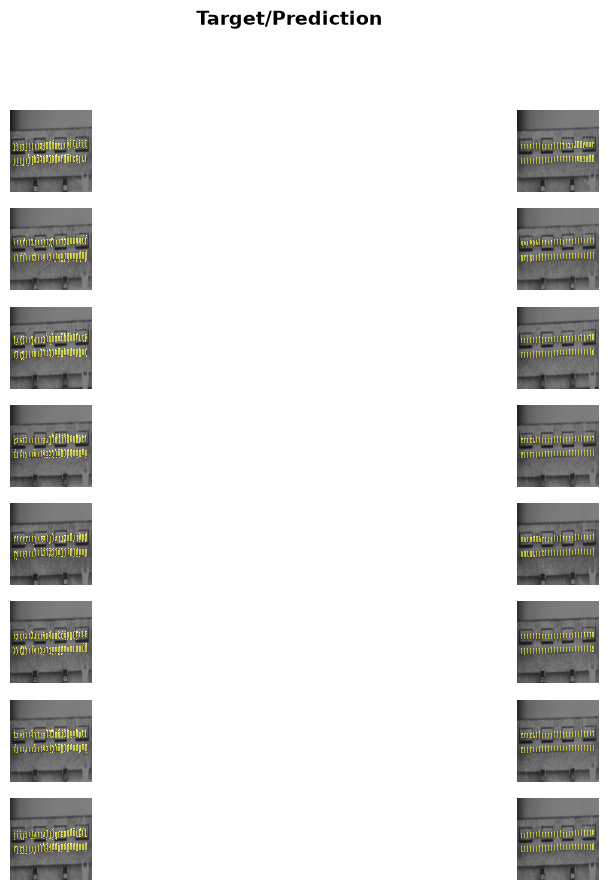

In [28]:
learner.show_results( max_n=8, figsize=(12,10), vmin=0, vmax=1, cmap=colormap )